In [64]:
import pandas as pd

df_zap = pd.read_csv('zap_data_22.csv')
df_calib = pd.read_csv('calib.csv')

print(df_zap)
print(df_calib)

              lat        lon   timestamp  speed  voltage  \
0             NaN        NaN  1704056413    NaN    25.20   
1             NaN        NaN  1704056636    NaN    25.20   
2             NaN        NaN  1704056661    NaN    25.20   
3             NaN        NaN  1704056751    NaN    25.20   
4             NaN        NaN  1704056727    NaN    25.20   
...           ...        ...         ...    ...      ...   
161529  56.070923  37.123569  1735678101    0.0    25.35   
161530  56.070923  37.123569  1735678251    0.0    25.35   
161531  56.070923  37.123569  1735678401    0.0    25.35   
161532  56.070923  37.123569  1735678551    0.0    25.35   
161533  56.070923  37.123569  1735678700    0.0    25.35   

                                                 can_data  
0                        {"LLS_0": 1477, "xLLS_71": 1477}  
1                        {"LLS_0": 1477, "xLLS_71": 1477}  
2                        {"LLS_0": 1477, "xLLS_71": 1477}  
3                        {"LLS_0": 1477

интерполяция

3

in out

1   2

2   3

4   5

1 -> 2

2 -> 3

3 -> 4

4 -> 5

In [65]:
import json

# Сначала преобразуем строковые представления словарей в реальные словари Python
df_zap['data'] = df_zap['can_data'].apply(lambda x: json.loads(x))

# Теперь создаем новый столбец LLS, извлекая значение LLS_0
df_zap['LLS'] = df_zap['data'].apply(lambda x: x.get('LLS_0'))

# Если нужно, можно удалить промежуточный столбец data
df_zap.drop(columns=['data'], inplace=True)
df_zap.drop(columns=['can_data'], inplace=True)

In [66]:
print(df_zap)

              lat        lon   timestamp  speed  voltage     LLS
0             NaN        NaN  1704056413    NaN    25.20  1477.0
1             NaN        NaN  1704056636    NaN    25.20  1477.0
2             NaN        NaN  1704056661    NaN    25.20  1477.0
3             NaN        NaN  1704056751    NaN    25.20  1477.0
4             NaN        NaN  1704056727    NaN    25.20  1477.0
...           ...        ...         ...    ...      ...     ...
161529  56.070923  37.123569  1735678101    0.0    25.35  3345.0
161530  56.070923  37.123569  1735678251    0.0    25.35  3345.0
161531  56.070923  37.123569  1735678401    0.0    25.35  3345.0
161532  56.070923  37.123569  1735678551    0.0    25.35  3345.0
161533  56.070923  37.123569  1735678700    0.0    25.35  3345.0

[161534 rows x 6 columns]


Задачи:

По каждому из файлов ([zap_data_22.cav](https://drive.google.com/file/d/1JYjNsFdcAzSr4sb1sGWc_kd-Hw4Cmklf/view?usp=sharing) [zap_data_33.csv](https://drive.google.com/file/d/1p98BIbgQVytpGYHanlCd_E6mdA1D0vgK/view?usp=sharing))


1.   Сделать 12 графиков скорости от времени
2.   Создать алгоритм заправок
3.   Сделать 12 графиков по заправкам и сливам (с интерполяцией данных через [calib.csv](https://drive.google.com/file/d/1dfSIZUovWuKA0uUYAc80KgqKNwTpegGi/view?usp=sharing))
4.   *Создать алгоритм сливов



# Пример графика


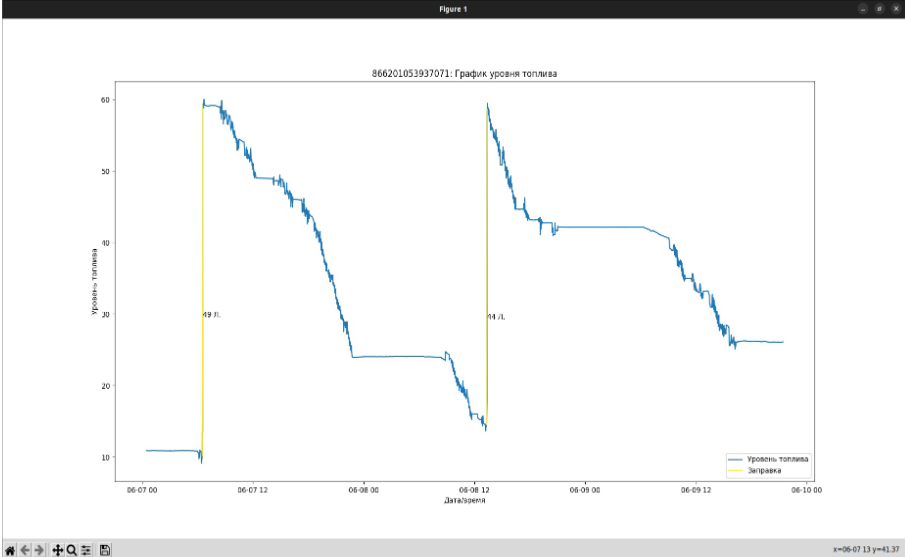

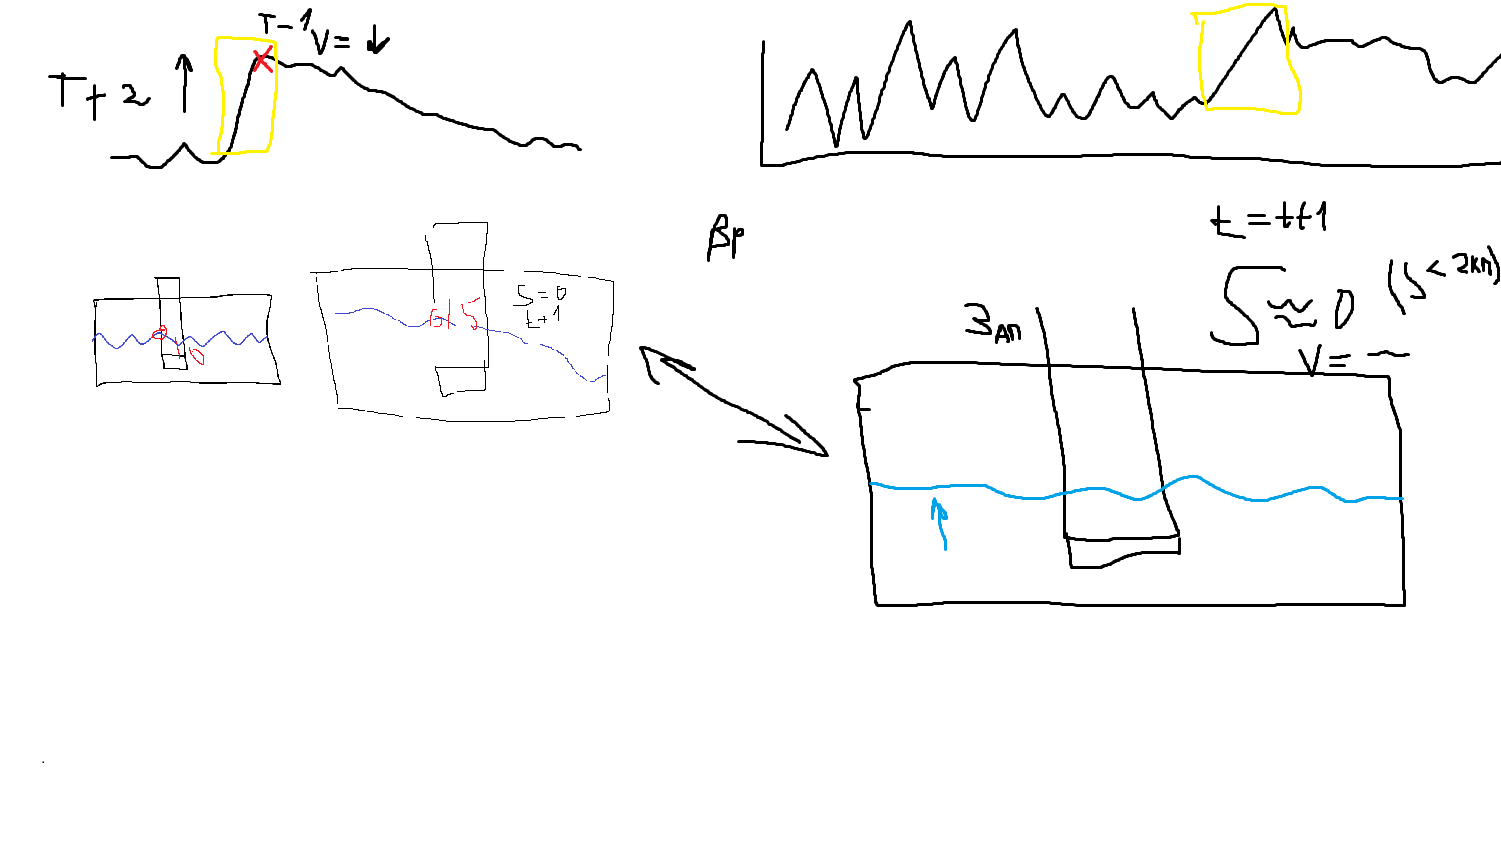

# Решение

## 1. Сделать 12 графиков скорости в зависимости от времени

In [67]:
# Для начала переведём timestamp в реальные временные данные
import datetime
df_zap['timestamp'] = pd.to_datetime(df_zap['timestamp'] * 1e9)

In [68]:
df_zap

,lat,lon,timestamp,speed,voltage,LLS
0,NaN,NaN,2023-12-31 21:00:13,NaN,25.20,1477.0
1,NaN,NaN,2023-12-31 21:03:56,NaN,25.20,1477.0
2,NaN,NaN,2023-12-31 21:04:21,NaN,25.20,1477.0
3,NaN,NaN,2023-12-31 21:05:51,NaN,25.20,1477.0
4,NaN,NaN,2023-12-31 21:05:27,NaN,25.20,1477.0
...,...,...,...,...,...,...
161529,56.070923,37.123569,2024-12-31 20:48:21,0.0,25.35,3345.0
161530,56.070923,37.123569,2024-12-31 20:50:51,0.0,25.35,3345.0
161531,56.070923,37.123569,2024-12-31 20:53:21,0.0,25.35,3345.0
161532,56.070923,37.123569,2024-12-31 20:55:51,0.0,25.35,3345.0


В датафрейме находятся данные за год с некоторой разницей во времени

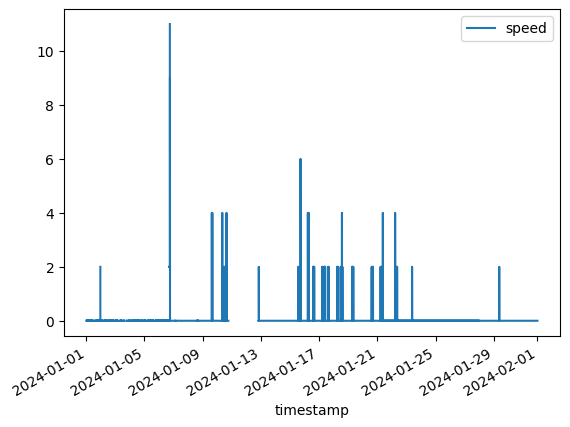

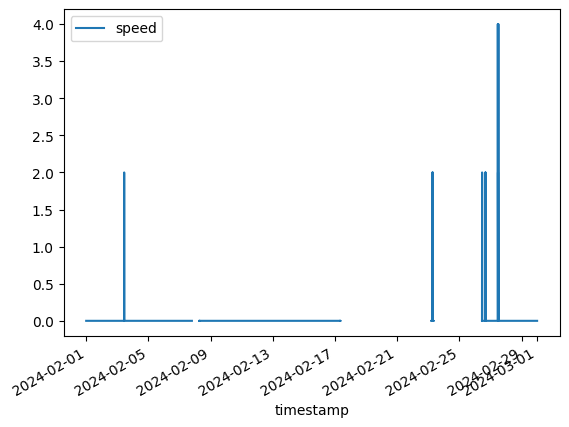

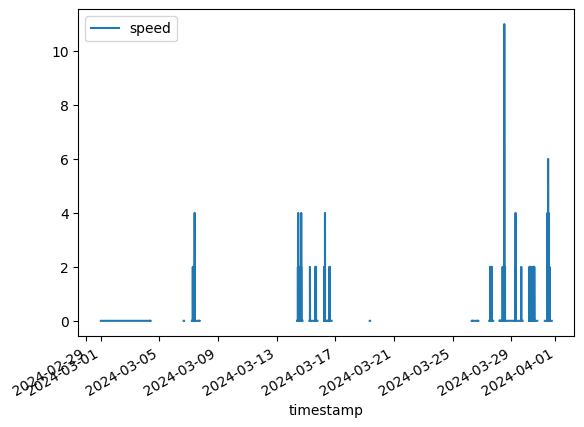

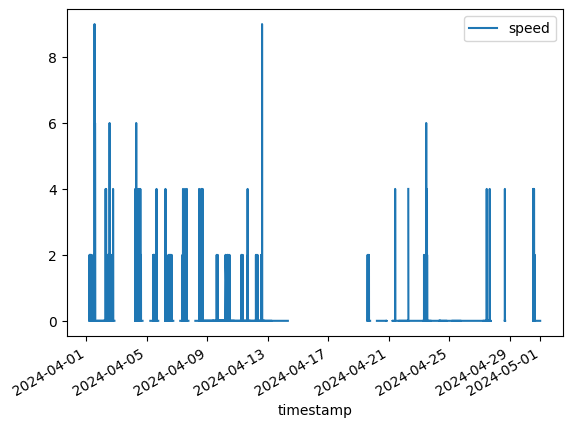

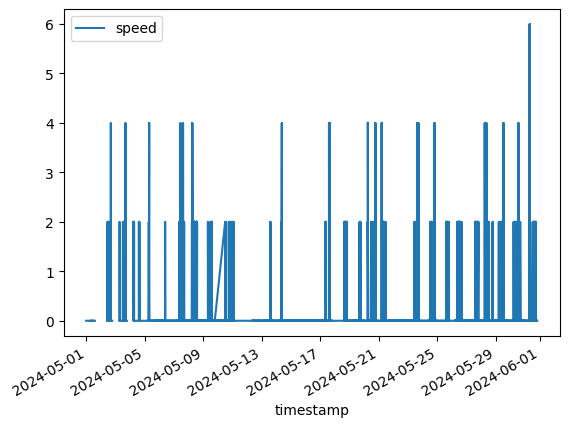

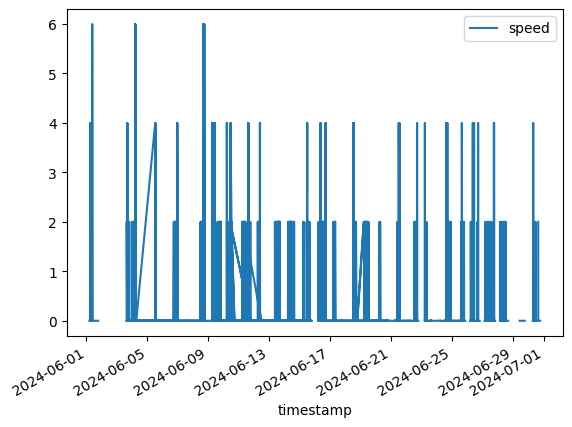

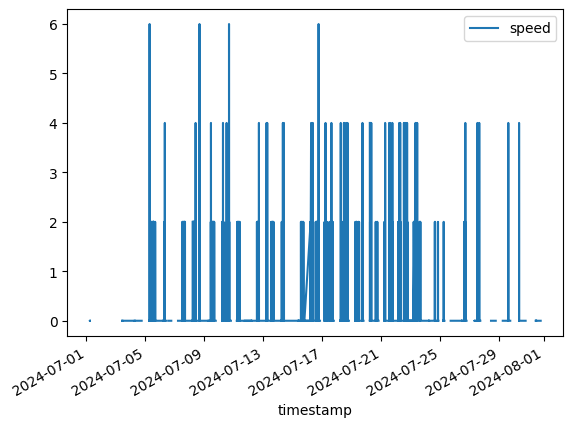

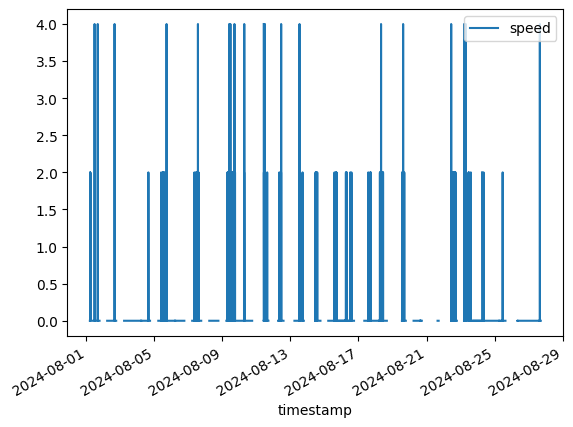

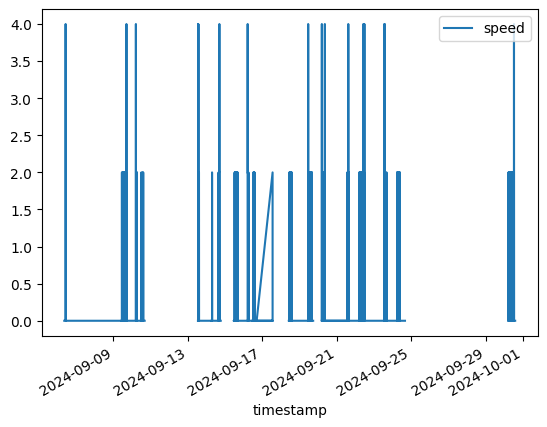

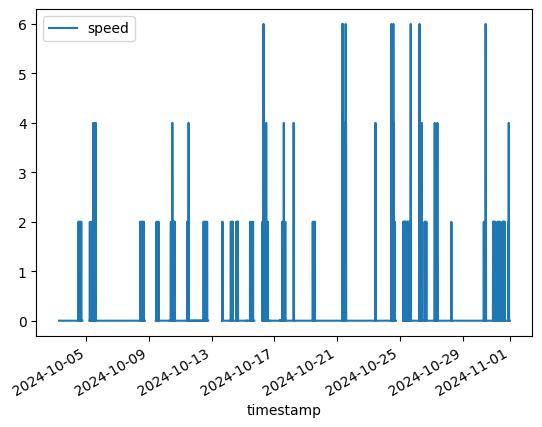

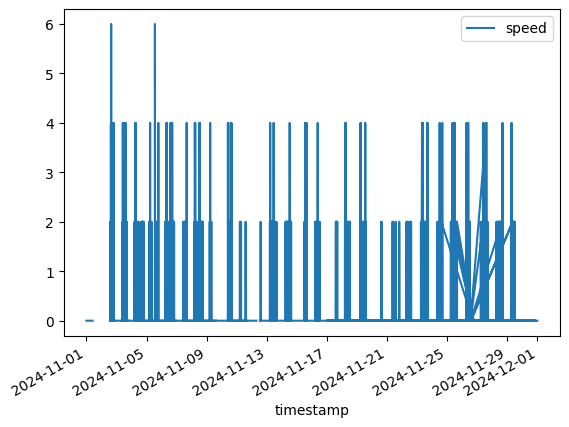

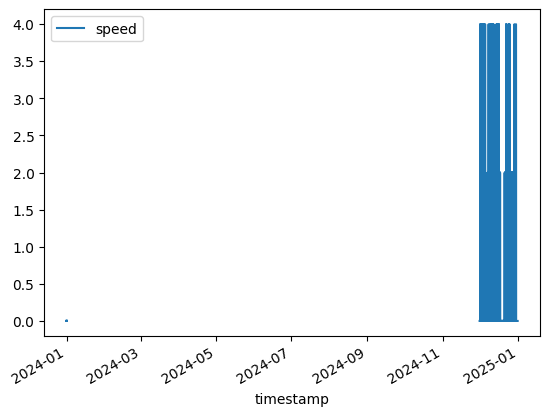

In [69]:
for i in range(1, 13):
    df_zap[df_zap['timestamp'].dt.month == i].plot(x='timestamp', y='speed')

Судя по всему эти данные не отсортированы по времени, либо в них есть сбои. Предполложим, что данные просто не отсортированы по времени.

In [70]:
df_zap = df_zap.sort_values(by='timestamp')

<Axes: xlabel='timestamp'>

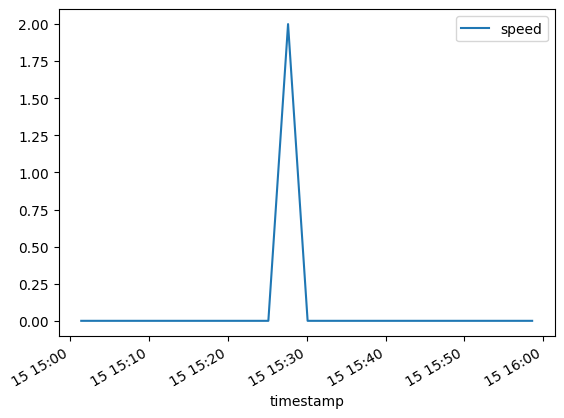

In [71]:
df_zap[(df_zap['timestamp'].dt.day_of_year == 15) & (df_zap['timestamp'].dt.hour == 15)].sort_values(by='timestamp').plot(x='timestamp', y='speed')

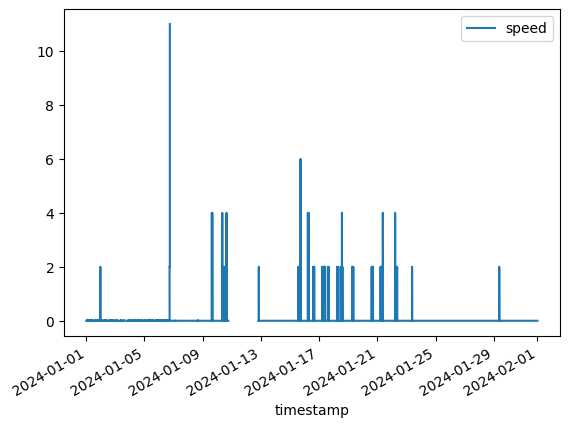

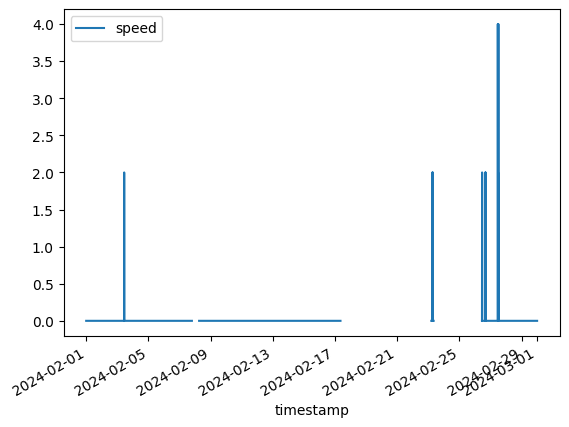

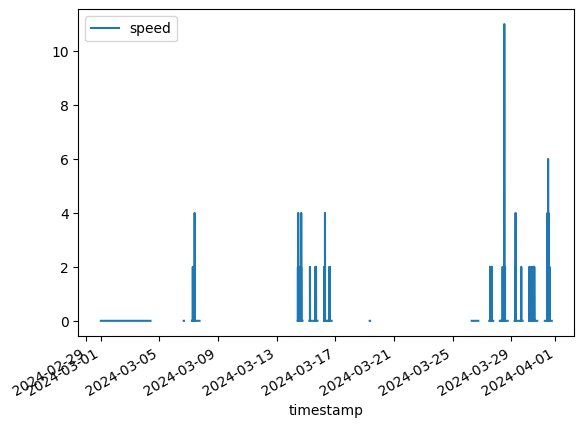

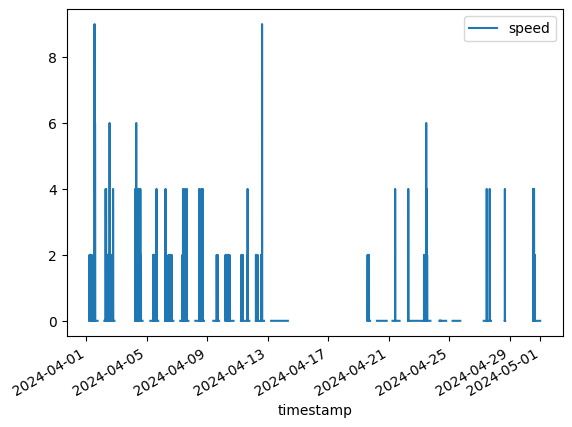

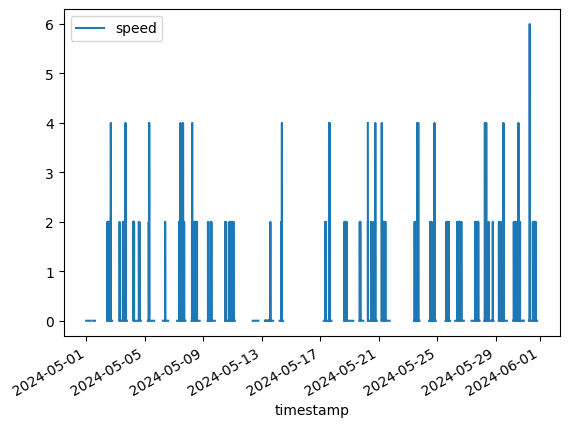

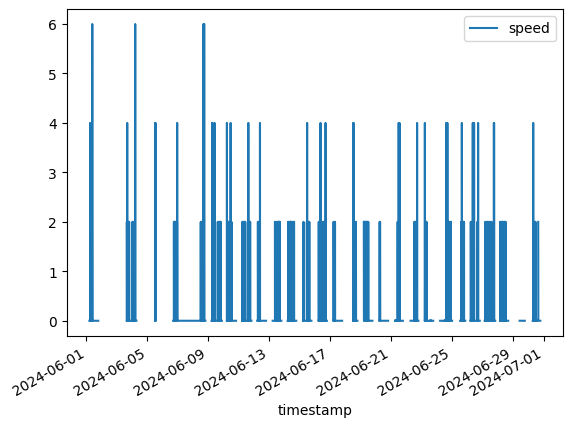

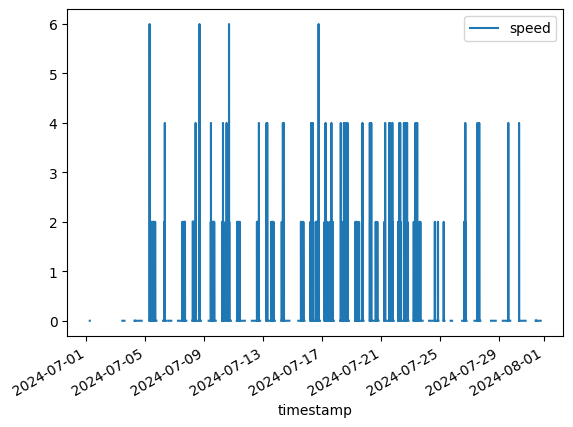

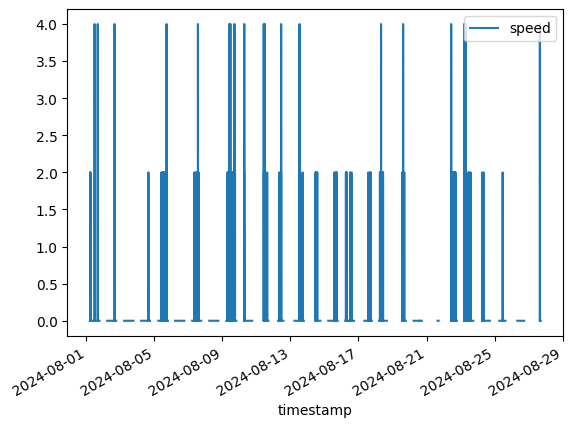

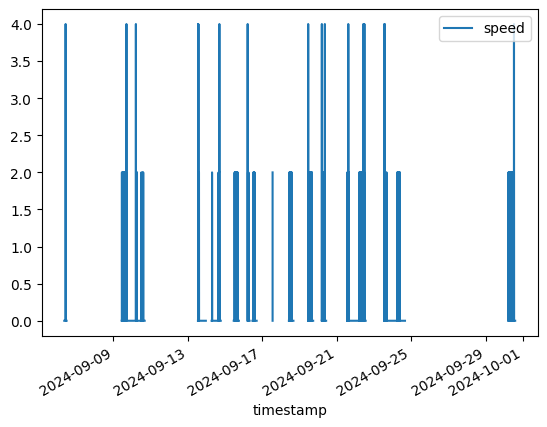

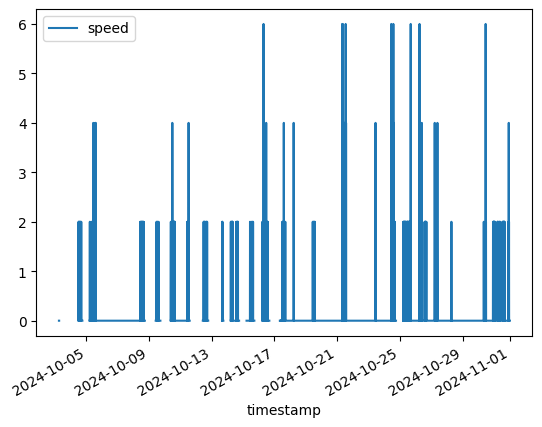

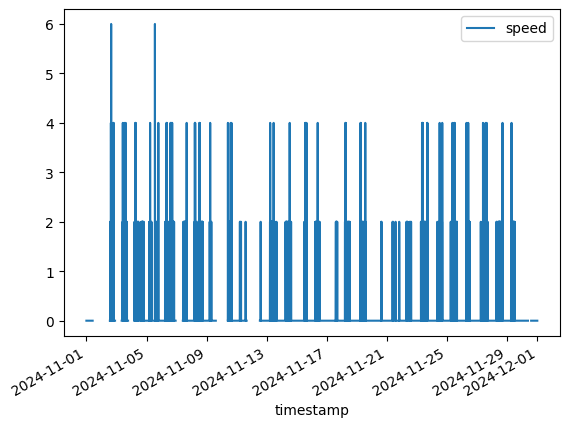

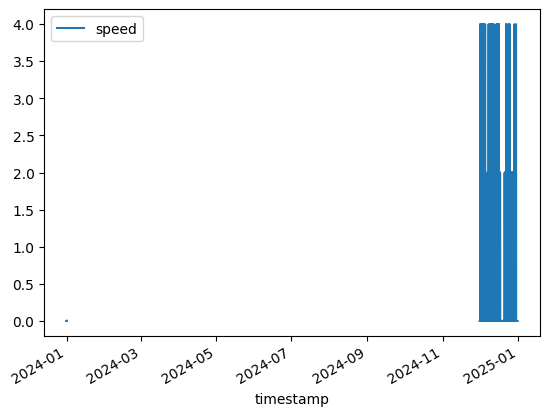

In [72]:
for i in range(1, 13):
    df_zap[df_zap['timestamp'].dt.month == i].plot(x='timestamp', y='speed')

Скорость похоже выражена не в километрах или милях в час, либо это особенность самого транспортного средства.

## 2. Создать алгоритм заправок

Предположим, что во время заправки для ТС характерно следующее:
1. Скорость околонулевая;
2. Координаты практически не меняются (возможны небольшие изменения, допустим в пределах 10-20 метров за счёт корректности работы датчиков GPS)
3. Топливо растёт в течение некоторого промежутка времени (допустим от 3 минут и не более 10 минут, иначе это скорее всего какое-то другое событие)

In [73]:
def mark_as_fill(df):
    pass

Введём столбец `fill_or_steal`, в который в дальнейшем будем записывать следующие значения:
- `1` - Заправка;
- `0` - Машина едет/стоит (никаких необычных ситуаций с топливом);
- `-1` - Топливо сливают.

In [74]:
df_zap['fill_or_steal'] = 0